# 44. Convolving a 1D PDF with detector resolution

**Objectives:**
- Convolve a normalized 1D intensity PDF (`LineshapeIntensity1D`) with a Gaussian resolution
  kernel (`GaussianResolution1D`) via `ConvolvedPDF1D`.
- Show the convolved PDF is smoother and wider than the true PDF.
- Confirm the convolved PDF still integrates to 1 over the finite observed window -- its
  "finite-observed-window normalization", not the raw-Gaussian normalization on the full line.

Run cells in order in a fresh kernel. Masses are in GeV. See `docs/convolution_resolution.md`.


In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: PDFs and kernels use complex128/float64.

import numpy as np
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    ConvolvedPDF1D, GaussianResolution1D, LineshapeIntensity1D,
    RelativisticBreitWigner, ResonanceContext,
)

## 1. The true PDF: a K*(892)0 lineshape

`LineshapeIntensity1D.from_context` reuses the same `RelativisticBreitWigner` implementation the
Dalitz amplitude model itself uses (running width, Blatt-Weisskopf barrier), turned into a
normalized 1D `|R(m)|^2` PDF over the full physical two-body mass interval.

In [2]:
context = ResonanceContext(
    parent_mass=5.27934,
    daughter_masses=(0.493677, 0.13957039),
    bachelor_mass=0.13957039,
    spin=1,
    pole_mass=0.8958,
    pole_width=0.0474,
    resonance_radius=4.0,
    parent_radius=4.0,
)
true_mass = LineshapeIntensity1D.from_context(
    RelativisticBreitWigner(), context, quadrature_order=512,
)
print(f"true mass window: [{true_mass.low:.4f}, {true_mass.high:.4f}] GeV")

true mass window: [0.6332, 5.1398] GeV


## 2. Convolve with a Gaussian detector response

`GaussianResolution1D(sigma, bias)` is the conditional resolution density `R(x_obs | x_true)`.
`ConvolvedPDF1D` numerically convolves `true_mass` with it, normalized on `[observed_low,
observed_high]` -- here the same physical window, so any probability that migrates outside it
under smearing is genuinely lost and renormalized away, exactly the "finite-observed-window
normalization" the class docstring describes.

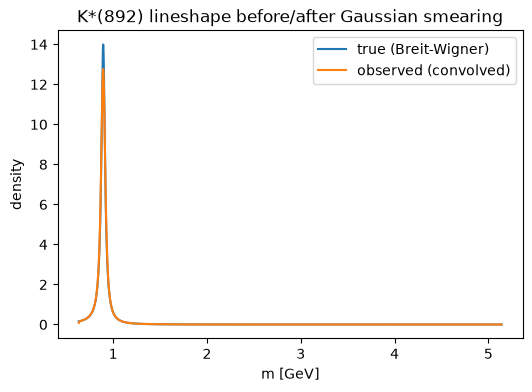

In [3]:
resolution = GaussianResolution1D(sigma=0.008, bias=0.0)

reconstructed_mass = ConvolvedPDF1D(
    true_mass,
    resolution,
    true_low=true_mass.low,
    true_high=true_mass.high,
    observed_low=true_mass.low,
    observed_high=true_mass.high,
    quadrature_order=192,
)

x = np.linspace(true_mass.low, true_mass.high, 3000)
y_true = np.asarray(true_mass(x))
y_obs = np.asarray(reconstructed_mass(x))

plt.figure(figsize=(6, 4))
plt.plot(x, y_true, label="true (Breit-Wigner)")
plt.plot(x, y_obs, label="observed (convolved)")
plt.xlabel("m [GeV]")
plt.ylabel("density")
plt.legend()
plt.title("K*(892) lineshape before/after Gaussian smearing")
plt.show()

## 3. The convolved PDF is smoother and wider

Compare the peak density (should drop under smearing, since probability spreads out) and an
approximate full-width-at-half-maximum (should grow).

In [4]:
def fwhm(x_grid, y_grid):
    half = y_grid.max() / 2.0
    above = np.where(y_grid >= half)[0]
    return x_grid[above[-1]] - x_grid[above[0]]

peak_true, peak_obs = y_true.max(), y_obs.max()
fwhm_true, fwhm_obs = fwhm(x, y_true), fwhm(x, y_obs)

print(f"peak density:  true={peak_true:.3f}  observed={peak_obs:.3f}")
print(f"FWHM:          true={fwhm_true*1000:.2f} MeV  observed={fwhm_obs*1000:.2f} MeV")
assert peak_obs < peak_true
assert fwhm_obs > fwhm_true

peak density:  true=13.992  observed=12.766
FWHM:          true=46.58 MeV  observed=52.59 MeV


## 4. The convolved PDF still integrates to 1

Despite the finite window and the probability lost near its edges under smearing, `ConvolvedPDF1D`
renormalizes by the retained-probability integral (`normalization()`), so the PDF it returns
integrates to exactly 1 over `[observed_low, observed_high]`.

In [5]:
integral_obs = np.trapezoid(y_obs, x)
print(f"convolved PDF integral over the observed window = {integral_obs:.6f}")
assert abs(integral_obs - 1.0) < 1e-3

convolved PDF integral over the observed window = 0.999652


## Summary and exercises

1. Increase `resolution.sigma` (e.g. to 0.03) and watch the observed peak flatten further and the
   integral-check assertion still hold -- more probability migrates near the boundary, but the
   PDF stays normalized on the finite window regardless.
2. Shrink the observed window to only the upper half of `[true_mass.low, true_mass.high]` and see
   `normalization()` drop noticeably below the full-window value, since more smeared probability
   now falls entirely outside the window.
3. Compare `ConvolvedPDF1D` with the generic (non-specialized) Gauss-Legendre convolution path by
   passing a hand-written kernel without a `convolve_pdf` method, and check the two give the same
   answer for a Gaussian kernel (`_numerator`'s two code paths).

Reference: `docs/convolution_resolution.md`.

Return to [the course guide](TUTORIALS.md).
